In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

cols = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
        "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num"]
df = pd.read_csv("../data/processed.cleveland.data",
                 header=None, names=cols, na_values="?")
df["target"] = (df["num"] > 0).astype(int)
df = df.drop(columns=["num"])

X = df.drop(columns=["target"]); y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scale_cols  = ["age", "trestbps", "chol", "thalach", "oldpeak"]
onehot_cols = ["cp", "restecg", "thal"]
pass_cols   = ["sex", "fbs", "exang", "slope", "ca"]

preprocess = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc", StandardScaler())]), scale_cols),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(drop="first", handle_unknown="ignore"))]), onehot_cols),
    ("pass", SimpleImputer(strategy="most_frequent"), pass_cols),
])

In [26]:
from sklearn.dummy import DummyClassifier

base = DummyClassifier(strategy="most_frequent")
base.fit(X_train, y_train)
print("无脑基线准确率:", base.score(X_test, y_test))   # 约 0.54

无脑基线准确率: 0.5409836065573771


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

pipe_lr  = Pipeline([("prep", preprocess),
                     ("clf", LogisticRegression(max_iter=1000, random_state=42))])
pipe_knn = Pipeline([("prep", preprocess),
                     ("clf", KNeighborsClassifier(n_neighbors=5))])
pipe_dt  = Pipeline([("prep", preprocess),
                     ("clf", DecisionTreeClassifier(max_depth=4, random_state=42))])
pipe_rf  = Pipeline([("prep", preprocess),
                     ("clf", RandomForestClassifier(n_estimators=200, random_state=42))])
pipe_svm = Pipeline([("prep", preprocess),
                     ("clf", SVC(probability=True, random_state=42))])

pipes = {"逻辑回归": pipe_lr, "KNN": pipe_knn, "决策树": pipe_dt,
         "随机森林": pipe_rf, "SVM": pipe_svm}

In [28]:
results = {}
for name, p in pipes.items():
    s = cross_val_score(p, X_train, y_train, cv=5, scoring="roc_auc")
    results[name] = s
    print(f"{name}: 交叉验证 AUC = {s.mean():.3f} ± {s.std():.3f}")

C:\Users\86135\.conda\envs\heart\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


逻辑回归: 交叉验证 AUC = 0.899 ± 0.046


C:\Users\86135\.conda\envs\heart\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


KNN: 交叉验证 AUC = 0.841 ± 0.040


C:\Users\86135\.conda\envs\heart\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


...

C:\Users\86135\.conda\envs\heart\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


随机森林: 交叉验证 AUC = 0.881 ± 0.039


C:\Users\86135\.conda\envs\heart\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\86135\.conda\envs\heart\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\86135\.conda\envs\heart\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
C:\Users\86135\.conda\envs\heart\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `

SVM: 交叉验证 AUC = 0.877 ± 0.051


C:\Users\86135\.conda\envs\heart\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


C:\Users\86135\.conda\envs\heart\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


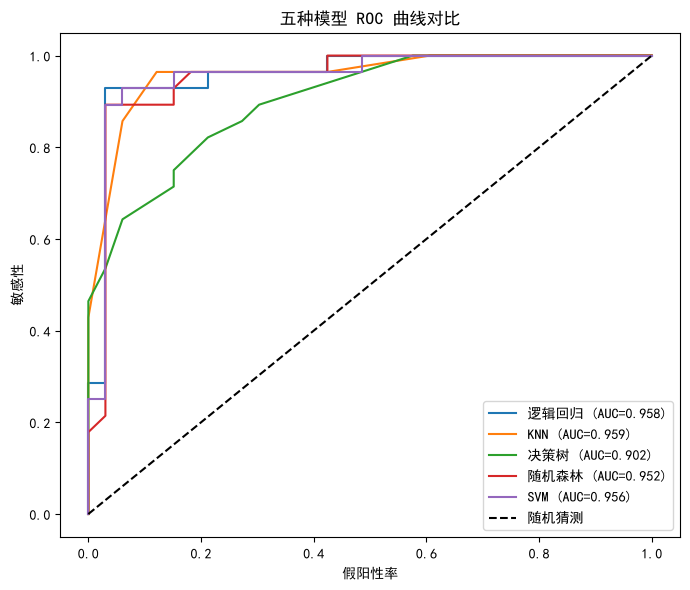

In [29]:
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, classification_report

plt.figure(figsize=(7, 6))
for name, p in pipes.items():
    p.fit(X_train, y_train)
    proba = p.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")
plt.plot([0, 1], [0, 1], "k--", label="随机猜测")
plt.xlabel("假阳性率"); plt.ylabel("敏感性")
plt.title("五种模型 ROC 曲线对比")
plt.legend(); plt.tight_layout()
plt.savefig("../figures/roc_compare.png", dpi=150); plt.show()

In [30]:
# 以表现最好的模型为例，看混淆矩阵
y_pred = pipe_lr.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["无病", "有病"]))

[[28  5]
 [ 2 26]]
              precision    recall  f1-score   support

          无病       0.93      0.85      0.89        33
          有病       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



In [31]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

pipe_xgb = Pipeline([("prep", preprocess),
                     ("clf", XGBClassifier(n_estimators=300, max_depth=3,
                                           learning_rate=0.05,
                                           eval_metric="logloss", random_state=42))])
pipe_lgbm = Pipeline([("prep", preprocess),
                      ("clf", LGBMClassifier(n_estimators=300, max_depth=3,
                                             learning_rate=0.05,
                                             random_state=42, verbose=-1))])

for name, p in {"XGBoost": pipe_xgb, "LightGBM": pipe_lgbm}.items():
    s = cross_val_score(p, X_train, y_train, cv=5, scoring="roc_auc")
    print(f"{name}: 交叉验证 AUC = {s.mean():.3f} ± {s.std():.3f}")

C:\Users\86135\.conda\envs\heart\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


XGBoost: 交叉验证 AUC = 0.865 ± 0.038


C:\Users\86135\.conda\envs\heart\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


LightGBM: 交叉验证 AUC = 0.869 ± 0.036


In [24]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "clf__n_estimators": [100, 200, 400],
    "clf__max_depth": [None, 4, 6, 8],
    "clf__min_samples_split": [2, 5, 10],
}
gs = GridSearchCV(pipe_rf, param_grid, cv=5, scoring="roc_auc", n_jobs=1)
gs.fit(X_train, y_train)
print("最佳参数:", gs.best_params_)
print("交叉验证最佳 AUC:", round(gs.best_score_, 3))

C:\Users\86135\.conda\envs\heart\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
C:\Users\86135\.conda\envs\heart\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
C:\Users\86135\.conda\envs\heart\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
C:\Users\86135\.conda\envs\heart\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


最佳参数: {'clf__max_depth': None, 'clf__min_samples_split': 10, 'clf__n_estimators': 100}
交叉验证最佳 AUC: 0.896


In [32]:
param_grid_lr = {"clf__C": [0.01, 0.1, 1, 10]}
gs_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=5, scoring="roc_auc", n_jobs=1)
gs_lr.fit(X_train, y_train)
print("逻辑回归最佳参数:", gs_lr.best_params_)
print("交叉验证最佳 AUC:", round(gs_lr.best_score_, 3))

C:\Users\86135\.conda\envs\heart\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
C:\Users\86135\.conda\envs\heart\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
C:\Users\86135\.conda\envs\heart\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
C:\Users\86135\.conda\envs\heart\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


逻辑回归最佳参数: {'clf__C': 1}
交叉验证最佳 AUC: 0.899


In [34]:
from sklearn.metrics import roc_auc_score

rng = np.random.default_rng(42)
proba = gs_lr.best_estimator_.predict_proba(X_test)[:, 1]  # 用你定选的模型
aucs = []
for _ in range(2000):
    idx = rng.integers(0, len(y_test), len(y_test))        # 有放回重采样
    if len(np.unique(y_test.iloc[idx])) < 2:
        continue
    aucs.append(roc_auc_score(y_test.iloc[idx], proba[idx]))
lo, hi = np.percentile(aucs, [2.5, 97.5])
print(f"测试集 AUC = {roc_auc_score(y_test, proba):.3f}，95% CI = [{lo:.3f}, {hi:.3f}]")

测试集 AUC = 0.958，95% CI = [0.896, 1.000]
